# X5: Reversible-jump MCMC with Eryn

**Development-stack exercise notebook (LATW `dev` branch).** There is no
Colab button: these exercises target the *development* versions of the LISA
Analysis Tools packages. Set the environment up by cloning LISAanalysistools
and running its installer (it lays every sibling repo out side by side and
editable-installs the development branches):

```bash
git clone https://github.com/lisa-analysis-tools/lisa-analysis-tools.git LISAanalysistools
bash LISAanalysistools/install.sh
```

For the workshop on the **pip-released** packages, use the
[`main` branch](https://github.com/lisa-analysis-tools/LATW/tree/main) instead
(branch policy: `main` &harr; pip releases, `dev` &harr; the `install.sh` stack).

In [1]:
import os

# Threading is pinned to 1 everywhere in this workshop (MPI-only policy;
# OMP-threaded kernels have caused out-of-memory kills on laptops).
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from copy import deepcopy
from lisatools.utils.constants import *

# Eryn's internals still import a legacy prior module (harmless); silence the
# DeprecationWarning so the output stays clean.
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [`X3`](X3_FixedDimMCMC.ipynb) every sampler ran at a **fixed** dimension: the
model had a set number of parameters and the chain only explored *their values*.
But the central question in a LISA analysis is often *how many* sources are in
the data at all &mdash; the model dimension is itself unknown. **Reversible-jump
MCMC** (RJMCMC, a.k.a. trans-dimensional MCMC) lets the sampler add and remove
components as it runs, so the *number* of sources becomes something you infer
rather than assume. This notebook builds three small RJ runs with
[Eryn](https://lisa-analysis-tools.github.io/Eryn): count an unknown number of 2-D
Gaussian pulses in noisy data, read the **posterior on that count**, and use a
reversible jump to do direct **model selection** (Gaussian vs. Cauchy pulse).
The companion informational notebook is
[`07` &sect; Reversible-jump MCMC](../../07_ErynSmallToLarge.ipynb); everything
here is a pure-Eryn toy (no LISA waveforms) and runs on the laptop CPU in a few
minutes. The same machinery, with real waveforms and specialised proposals, is
exactly how the global fit counts galactic binaries.

### How these exercises work

Each exercise is one of two kinds:

- **Task N** &mdash; you *write code* toward a stated goal. In this answer
  notebook the solution cells are filled in; in the generated student notebook
  they are blanked (a whole cell, or just the key solution lines for a
  fill-in-the-blank). Every Task ends with a **Useful documentation:** list
  pointing at the Sphinx/Eryn API docs and the relevant informational-notebook
  section.
- **Question** (a `### Question` heading) &mdash; a short *discussion* prompt.
  No code required; the answer sketch here is for the group conversation.

The tasks build on each other in order, so run them top to bottom.

## Task 1: Count an unknown number of Gaussian pulses

Our data is a noisy 2-D image containing some number of Gaussian *pulses* (each
a bump with an amplitude and an $(x, y)$ centre; the width is fixed and known).
We do **not** tell the sampler how many pulses there are &mdash; it must infer
that. In Eryn this is a single **branch** (model type) named `"pulse"` whose
**leaf** count is variable: `nleaves_min`&ndash;`nleaves_max` bounds the number
of pulses, and setting `rj_moves=True` turns on reversible-jump proposals that
add or remove one leaf at a time (drawing new leaves from the prior). The
per-leaf *coordinates* live in a `(ntemps, nwalkers, nleaves_max, ndim)` array
and a boolean `inds` array of shape `(ntemps, nwalkers, nleaves_max)` marks
which leaves are currently *on*. Because the affine-invariant stretch move is
undefined across changing dimension, in-model steps use a
[`GaussianMove`](https://lisa-analysis-tools.github.io/Eryn/user/moves.html#eryn.moves.GaussianMove).

The grid, the injected pulses, the pulse model, and the Gaussian log-likelihood
are **provided below**. Your job is to configure and run the RJ sampler, then
plot the recovered pulses over the data.

Useful documentation:
* [`EnsembleSampler`](https://lisa-analysis-tools.github.io/Eryn/user/ensemble.html#eryn.ensemble.EnsembleSampler)
  (`rj_moves`, `nleaves_max`, `nleaves_min`, `branch_names`)
* [`State`](https://lisa-analysis-tools.github.io/Eryn/user/state.html#eryn.state.State)
  (the `coords` / `inds` structure) /
  [`ProbDistContainer`](https://lisa-analysis-tools.github.io/Eryn/user/prior.html#eryn.prior.ProbDistContainer),
  [`UniformDistribution`](https://lisa-analysis-tools.github.io/Eryn/user/prior.html)
* [`GaussianMove`](https://lisa-analysis-tools.github.io/Eryn/user/moves.html#eryn.moves.GaussianMove)
* Informational notebook: see [`07` &sect; Reversible-jump MCMC](../../07_ErynSmallToLarge.ipynb)
  (branches, leaves, `inds`, and `coords`)

In [2]:
# imports
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.priors import ProbDistContainer, UniformDistribution
from eryn.moves import GaussianMove

**Provided:** the grid, the pulse model `model_field` (a sum of fixed-width 2-D
Gaussians, vectorised over leaves and returning zeros for an empty model), the
true injected pulses, and a fixed-noise Gaussian log-likelihood. Eryn calls the
single-branch likelihood with the active-leaf coordinate block `params` of shape
`(nleaves_on, 3)` (or `None` when a walker has no leaves).

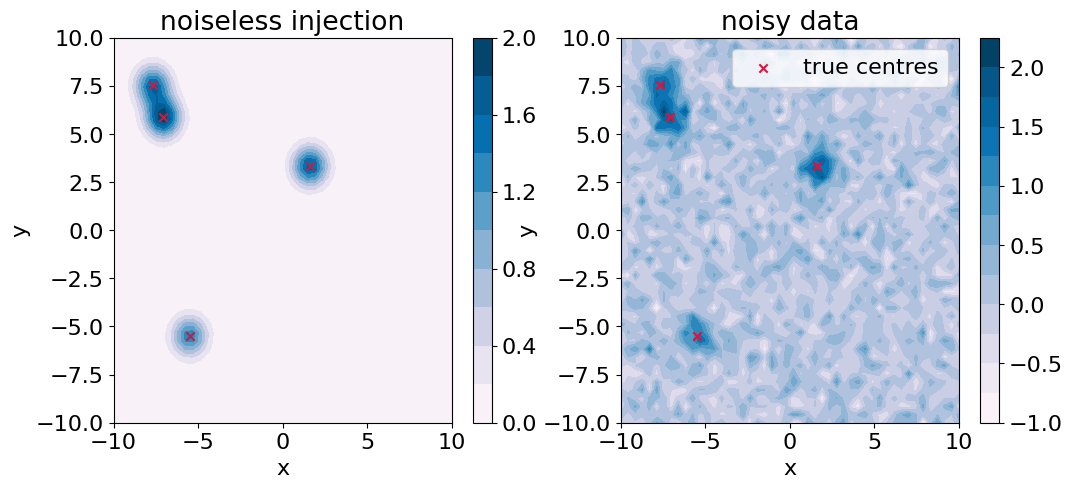

In [3]:
lowlim, highlim = -10.0, 10.0     # square domain in x and y
num = 48                          # grid points per axis
spread = 0.7                      # fixed, known pulse width
noise_sigma = 0.3                 # known noise standard deviation
npulses_true = 4                  # (the sampler is NOT told this)

x, y = np.mgrid[lowlim:highlim:complex(0, num), lowlim:highlim:complex(0, num)]

def model_field(params):
    """Sum of fixed-width 2-D Gaussian pulses on the (x, y) grid.

    params: array (nleaves_on, 3) of (amplitude, x-centre, y-centre), or None.
    """
    if params is None or len(params) == 0:
        return np.zeros_like(x)
    a = params[:, 0][:, None, None]
    b = params[:, 1][:, None, None]
    c = params[:, 2][:, None, None]
    g = a * np.exp(-0.5 * ((x[None] - b) ** 2 + (y[None] - c) ** 2) / spread ** 2)
    return g.sum(axis=0)

def log_like_pulses(params, data):
    template = model_field(params)
    return -0.5 * np.sum((data - template) ** 2) / noise_sigma ** 2

# inject npulses_true pulses at random amplitudes/centres, add white noise
np.random.seed(42)
edge = 2.0
amp_true = np.random.uniform(1.0, 2.0, size=npulses_true)
cen_true = np.random.uniform(lowlim + edge, highlim - edge, size=(npulses_true, 2))
inj_params = np.concatenate([amp_true[:, None], cen_true], axis=1)
injection = model_field(inj_params)
data = injection + noise_sigma * np.random.randn(num, num)

fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 5))
for ax, field, title in ((a0, injection, 'noiseless injection'), (a1, data, 'noisy data')):
    cf = ax.contourf(x, y, field, 12, cmap='PuBu')
    ax.scatter(cen_true[:, 0], cen_true[:, 1], marker='x', color='crimson', label='true centres')
    ax.set(xlabel='x', ylabel='y', title=title)
    fig.colorbar(cf, ax=ax)
a1.legend(loc='upper right')
plt.show()

Choose the sampler shape. Use tempering (`ntemps`) so walkers can cross between
pulse configurations. The one branch is `"pulse"` with `ndim = 3`; allow from 0
up to a comfortable ceiling of leaves (more than you expect to need).

In [4]:
# clear
ntemps, nwalkers = 8, 20
branch_names = ["pulse"]
ndims = {"pulse": 3}                 # (amplitude, x-centre, y-centre)
nleaves_max = {"pulse": 8}           # up to 8 pulses allowed
nleaves_min = {"pulse": 0}           # ...down to none

Build the per-leaf prior: uniform on amplitude and on each centre coordinate.

In [5]:
# clear
priors = {
    "pulse": ProbDistContainer({
        0: UniformDistribution(0.5, 2.5),        # amplitude
        1: UniformDistribution(lowlim, highlim), # x-centre
        2: UniformDistribution(lowlim, highlim), # y-centre
    })
}

Give the in-model (fixed-dimension) step a `GaussianMove` with a small diagonal
covariance &mdash; one entry per parameter, scaled to each parameter's range.

In [6]:
# clear
cov = {"pulse": np.diag([0.02, 0.1, 0.1])}
moves = GaussianMove(cov)

Instantiate the sampler. The reversible jump is switched on with
`rj_moves=True`; pass `moves` for the in-model steps and the `nleaves_*` bounds
for the trans-dimensional ones. The data is handed to the likelihood via `args`.

In [7]:
# clear
sampler = EnsembleSampler(
    nwalkers,
    ndims,
    log_like_pulses,
    priors,
    args=[data],
    tempering_kwargs=dict(ntemps=ntemps),
    nbranches=len(branch_names),
    branch_names=branch_names,
    nleaves_max=nleaves_max,
    nleaves_min=nleaves_min,
    moves=moves,
    rj_moves=True,
)

Seed the walkers. Draw a full `(ntemps, nwalkers, nleaves_max, ndim)` block of
coordinates from the prior, then use `inds` to switch **on just one leaf per
walker** to start &mdash; the reversible jump will add the rest. Wrap the two in
a `State`.

In [8]:
# clear
coords = {
    name: priors[name].rvs(size=(ntemps, nwalkers, nleaves_max[name]))
    for name in branch_names
}
inds_tmp = np.zeros(coords["pulse"].shape[:-1], dtype=bool)
inds_tmp[:, :, 0] = True             # start every walker with exactly one pulse
state = State(coords, inds={"pulse": inds_tmp})

Run a short chain with a burn-in. **This is deliberately short** (see the note
after Task 2).

In [9]:
# clear
nsteps, burn = 1500, 600
sampler.run_mcmc(state, nsteps, burn=burn, progress=True, thin_by=1)

  0%|          | 0/600 [00:00<?, ?it/s]

  1%|          | 5/600 [00:00<00:13, 44.10it/s]

  2%|▏         | 10/600 [00:00<00:13, 42.52it/s]

  2%|▎         | 15/600 [00:00<00:13, 44.20it/s]

  3%|▎         | 20/600 [00:00<00:13, 44.05it/s]

...

 99%|█████████▉| 1490/1500 [01:11<00:00, 20.69it/s]

100%|█████████▉| 1493/1500 [01:11<00:00, 21.16it/s]

100%|█████████▉| 1496/1500 [01:11<00:00, 20.95it/s]

100%|█████████▉| 1499/1500 [01:11<00:00, 20.63it/s]

100%|██████████| 1500/1500 [01:11<00:00, 20.93it/s]

Plot the recovered pulses: overlay every *on* leaf from the cold chain (temperature
index 0) on the data. Use `get_chain()` and `get_inds()` and keep only the active
leaves. The cloud of recovered centres should sit on the injected pulses.

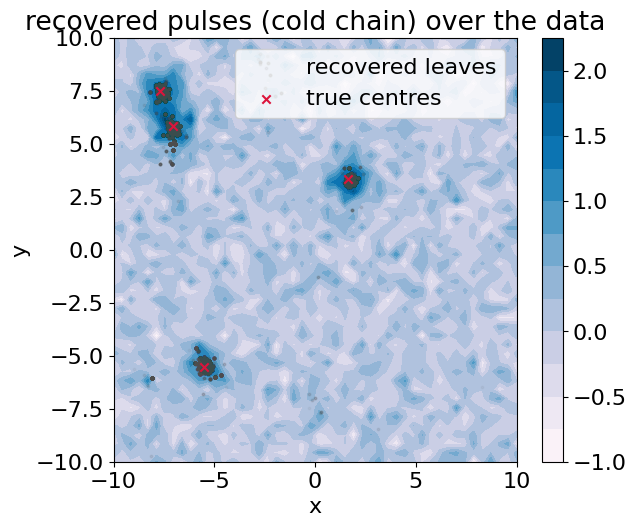

In [10]:
# clear
chain = sampler.get_chain()["pulse"]     # (nsteps, ntemps, nwalkers, nleaves, ndim)
inds = sampler.get_inds()["pulse"]       # (nsteps, ntemps, nwalkers, nleaves)
cold = chain[:, 0][inds[:, 0]]           # active leaves, cold chain -> (N, 3)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
cf = ax.contourf(x, y, data, 12, cmap='PuBu')
ax.scatter(cold[:, 1], cold[:, 2], s=3, color='0.3', alpha=0.05, label='recovered leaves')
ax.scatter(cen_true[:, 0], cen_true[:, 1], marker='x', color='crimson', label='true centres')
ax.set(xlabel='x', ylabel='y', title='recovered pulses (cold chain) over the data')
ax.legend(loc='upper right')
fig.colorbar(cf, ax=ax)
plt.show()

## Task 2: The posterior on the number of pulses

The reversible jump gives you something a fixed-dimension run cannot: a
**posterior over the model count itself**. Every cold-chain sample has some
number of active leaves, and the histogram of that number *is* the posterior on
"how many pulses are in the data." Read the per-step leaf counts straight from
the sampler with `get_nleaves()` (shape `(nsteps, ntemps, nwalkers)` per branch;
take temperature index 0 for the cold chain) and histogram them against the true
count.

Useful documentation:
* [`EnsembleSampler.get_nleaves`](https://lisa-analysis-tools.github.io/Eryn/user/ensemble.html#eryn.ensemble.EnsembleSampler) /
  [`Backend`](https://lisa-analysis-tools.github.io/Eryn/user/backend.html#eryn.backends.Backend)
* Informational notebook: see [`07` &sect; Reversible-jump MCMC](../../07_ErynSmallToLarge.ipynb)

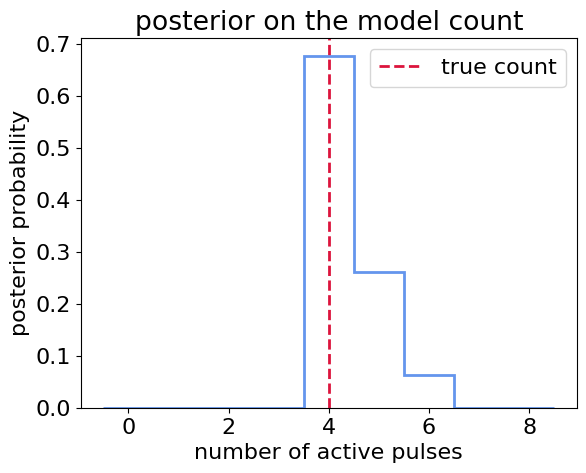

posterior on count: {4: 0.677, 5: 0.26, 6: 0.063, 7: 0.0}


In [11]:
# clear
nleaves = sampler.get_nleaves()["pulse"][:, 0].flatten()   # cold-chain leaf counts
bins = np.arange(0, nleaves_max["pulse"] + 2) - 0.5
plt.hist(nleaves, bins=bins, density=True, histtype='step', lw=2, color='#6495ed')
plt.axvline(npulses_true, ls='--', lw=2, color='crimson', label='true count')
plt.xlabel('number of active pulses'); plt.ylabel('posterior probability')
plt.title('posterior on the model count'); plt.legend()
plt.show()

vals, counts = np.unique(nleaves, return_counts=True)
print("posterior on count:", dict(zip(vals.tolist(), (counts / counts.sum()).round(3).tolist())))

> **This chain is deliberately short and NOT converged.** With a few hundred
> post-burn-in steps the count posterior is noisy and depends on the seed and on
> the exact noise draw; a real analysis needs many more steps, a considered
> burn-in, and a convergence check (autocorrelation time, multiple chains). We
> read it anyway to see the posterior forming &mdash; it should concentrate near
> the true count, with a tail toward one or two *extra* low-amplitude pulses that
> the noise can support.

### Question

What does the reversible jump tell you here that a **fixed-dimension** run
(as in `X3`) could not?

*Discussion.* A fixed-dimension sampler answers "given exactly $k$ pulses, where
are they?" &mdash; you must *choose* $k$ up front, and to compare choices you
would run several fixed-$k$ analyses and weigh their evidences by hand. RJMCMC
folds that choice *into* the sampling: by adding and removing leaves it explores
models of different dimension in one run, so the fraction of time it spends at
each leaf count **is** the posterior on the number of sources, already marginalised
over where those sources are. In a LISA global fit you never know a priori how
many galactic binaries (or how many resolvable sources of any kind) are present;
the number is a parameter, and only a trans-dimensional sampler infers it directly.

### Question

How would raising the **noise level** change this count posterior, and why?

*Discussion.* Louder noise lowers the signal-to-noise of each pulse. The faintest
injected pulses stop being clearly distinguishable from a noise fluctuation, so the
sampler spends more time in models that *drop* them &mdash; the posterior mass
shifts toward **fewer** pulses and broadens. Conversely, at high noise a chance
noise bump can look pulse-like and get *added*, so you also see spurious extra
leaves. Either way the posterior widens: with more noise the data simply constrain
the count less, and the honest inference is a broader distribution rather than a
sharp spike at the truth. (Lowering the noise sharpens the peak onto the true
count &mdash; try editing `noise_sigma` and re-running.)

## Task 3: Model selection with a reversible jump

Reversible jump also does direct **model comparison**. Here two competing models
explain the same 1-D data: a **Gaussian** pulse and a **Cauchy** (Lorentzian)
pulse, each with an amplitude and a centre. We make each its own branch with
`nleaves_max = 1` and `nleaves_min = 0`, and start every walker with *exactly
one* of the two switched on. The reversible jump then proposes to switch which
model is active, so the sampler hops between "this is a Gaussian" and "this is a
Cauchy." The fraction of cold-chain samples in each model is a direct estimate of
the **posterior odds ratio** &mdash; no separate evidence integral needed (this
holds well when the two models are competitive; see the Question).

The two pulse shapes, the branch-aware likelihood, and the injected data are
**provided**. Eryn calls a multi-branch likelihood with a list `params = [gauss,
cauchy]`, where exactly one entry is the `(1, 2)` coordinate block and the other
is `None`.

Useful documentation:
* [`EnsembleSampler`](https://lisa-analysis-tools.github.io/Eryn/user/ensemble.html#eryn.ensemble.EnsembleSampler)
  (multiple `branch_names`, `rj_moves`) /
  [`State`](https://lisa-analysis-tools.github.io/Eryn/user/state.html#eryn.state.State)
* [`get_nleaves`](https://lisa-analysis-tools.github.io/Eryn/user/backend.html#eryn.backends.Backend)
* Informational notebook: see [`07` &sect; Reversible-jump MCMC](../../07_ErynSmallToLarge.ipynb)

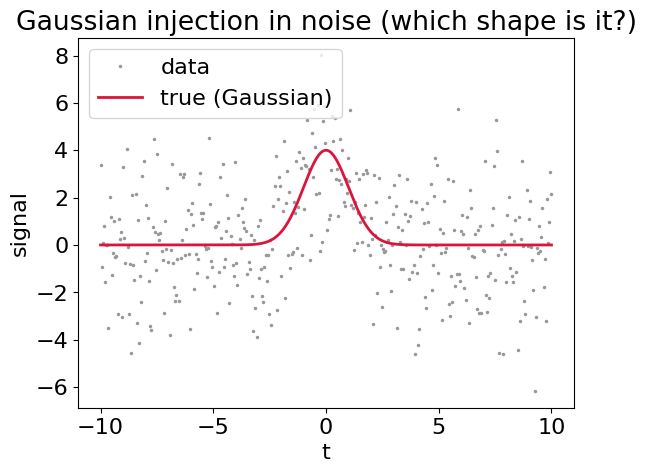

In [12]:
# provided: two pulse shapes, a branch-aware likelihood, and the injected data
from scipy.stats import cauchy

t = np.linspace(-10.0, 10.0, 400)

def gaussian_pulse(t, a, b):
    return a * np.exp(-0.5 * (t - b) ** 2)

def cauchy_pulse(t, a, b):
    return a * cauchy.pdf(t - b)

def log_like_models(params, t, data, noise_sigma):
    gauss_p, cauchy_p = params            # exactly one is not None
    if gauss_p is not None:
        template = gaussian_pulse(t, *gauss_p[0])
    else:
        template = cauchy_pulse(t, *cauchy_p[0])
    return -0.5 * np.sum(((data - template) / noise_sigma) ** 2)

# inject a GAUSSIAN pulse in fairly heavy noise, so the two models compete
noise_sigma_1d = 2.0
amp_true, mean_true = 4.0, 0.0
np.random.seed(7)
injection_1d = gaussian_pulse(t, amp_true, mean_true)
data_1d = injection_1d + noise_sigma_1d * np.random.randn(t.size)

plt.plot(t, data_1d, '.', ms=3, color='0.6', label='data')
plt.plot(t, injection_1d, color='crimson', lw=2, label='true (Gaussian)')
plt.xlabel('t'); plt.ylabel('signal'); plt.legend()
plt.title('Gaussian injection in noise (which shape is it?)')
plt.show()

Set up the two branches. Both are 2-D (`amplitude`, `centre`), both allowed
0 or 1 leaf, with identical priors that span the injected values.

In [13]:
# clear
ntemps, nwalkers = 8, 20
branch_names = ["gauss", "cauchy"]
ndims = {"gauss": 2, "cauchy": 2}
nleaves_max = {"gauss": 1, "cauchy": 1}
nleaves_min = {"gauss": 0, "cauchy": 0}
priors = {
    name: ProbDistContainer({
        0: UniformDistribution(0.0, 20.0),        # amplitude
        1: UniformDistribution(-10.0, 10.0),      # centre
    })
    for name in branch_names
}
moves = GaussianMove({name: np.diag([0.1, 0.1]) for name in branch_names})

Instantiate the two-branch sampler with the reversible jump on. `Tmax=np.inf`
puts a fully flat (prior-only) chain at the top of the ladder so the models mix
freely.

In [14]:
# clear
sampler2 = EnsembleSampler(
    nwalkers,
    ndims,
    log_like_models,
    priors,
    args=(t, data_1d, noise_sigma_1d),
    tempering_kwargs=dict(ntemps=ntemps, Tmax=np.inf),
    nbranches=len(branch_names),
    branch_names=branch_names,
    nleaves_max=nleaves_max,
    nleaves_min=nleaves_min,
    moves=moves,
    rj_moves=True,
)

Seed the walkers so that **each starts in exactly one model** &mdash; draw a
random Gaussian-or-Cauchy assignment and set the matching `inds` entry to True
(and only that one).

In [15]:
# clear
start = {name: priors[name].rvs(size=(ntemps, nwalkers, 1)) for name in branch_names}
which = np.random.randint(0, 2, size=(ntemps, nwalkers, 1))
inds = {name: np.zeros((ntemps, nwalkers, 1), dtype=bool) for name in branch_names}
inds["gauss"][which == 0] = True
inds["cauchy"][which == 1] = True
assert np.all(inds["gauss"].astype(int) + inds["cauchy"].astype(int) == 1)
start_state = State(start, inds=inds)

Run a short chain with a burn-in.

In [16]:
# clear
sampler2.run_mcmc(start_state, 800, burn=200, progress=True)

  0%|          | 0/200 [00:00<?, ?it/s]

  2%|▏         | 3/200 [00:00<00:06, 29.78it/s]

  3%|▎         | 6/200 [00:00<00:06, 29.24it/s]

  5%|▌         | 10/200 [00:00<00:06, 30.13it/s]

  7%|▋         | 14/200 [00:00<00:06, 30.18it/s]

...

 98%|█████████▊| 787/800 [00:26<00:00, 30.12it/s]

 99%|█████████▉| 791/800 [00:26<00:00, 30.07it/s]

 99%|█████████▉| 795/800 [00:26<00:00, 30.24it/s]

100%|█████████▉| 799/800 [00:26<00:00, 30.17it/s]

100%|██████████| 800/800 [00:26<00:00, 29.94it/s]

Compute the posterior odds ratio: the fraction of cold-chain samples in each
model. `get_nleaves()[name][:, 0]` is 1 when that model is active and 0 when it
is not, so its mean is the posterior probability of that model.

In [17]:
# clear
nl = sampler2.get_nleaves()
p_gauss = nl["gauss"][:, 0].sum() / np.prod(nl["gauss"][:, 0].shape)
p_cauchy = 1.0 - p_gauss
print(f"P(Gaussian) = {p_gauss:.3f}   P(Cauchy) = {p_cauchy:.3f}")
print(f"posterior odds  Gaussian : Cauchy  =  {p_gauss / p_cauchy:.2f} : 1")

P(Gaussian) = 0.920   P(Cauchy) = 0.080
posterior odds  Gaussian : Cauchy  =  11.49 : 1


### Question

What is the role of the **prior on model dimension** here, and how does
reversible jump build in Occam's razor?

*Discussion.* Adding a pulse (or choosing the more flexible shape) always lets the
model fit the data a little better, so on likelihood alone the sampler would keep
piling on components. What stops it is that every extra dimension spreads the same
unit of prior probability over a *larger* parameter volume: the reversible-jump
acceptance ratio carries a prior-volume factor that **penalises** the bigger model
unless the data reward it enough to pay for that extra volume. This is the
**Bayesian Occam factor**, and it is automatic &mdash; the posterior on the count
in Task 2 peaks at the true number rather than at `nleaves_max` precisely because
of it. It also means your choice of prior on the dimension (and the per-leaf
parameter priors) is not cosmetic: a prior that favours many components, or very
broad per-leaf priors, shifts the balance. In Task 3 the odds ratio is a clean
estimate **while both models are visited often**; once one model is so favoured
that the chain essentially never proposes into the other, the fraction saturates
at 0 or 1 and you can no longer read the ratio from occupancy &mdash; you would
fall back to estimating each model's evidence (e.g. thermodynamic integration, as
in `X3`) to get the Bayes factor.

### Where this goes next

You have now let the sampler infer *how many* things are in the data and *which
model* they follow &mdash; the trans-dimensional step that separates a global fit
from a fixed-parameter one. In [`X6`](X6_GalacticBinaryMCMC.ipynb) the same
reversible jump runs over real **galactic-binary** waveforms instead of toy
pulses, and in the full LISA global fit it counts thousands of overlapping
sources at once. Nothing changes about *how the reversible jump works* &mdash;
only the per-leaf model (a GB, MBH, or EMRI waveform) and the specialised
proposals that make the search tractable.